# 02 — Exploratory Data Analysis: Space Missions

**Purpose:** Understand the landscape — distributions, patterns, relationships, and the first layer of the agency/country comparison story.  
**Approach:** Every section follows: *visual → observation → statistical backing*. A chart alone is opinion; a chart plus a significance test is a finding.

---
**Sections**
1. Setup
2. Mission Landscape Overview
3. Agency Profiling
4. Country Profiling
5. Government vs Private
6. Mission Category Distribution
7. Cost & Duration Distributions
8. EDA Summary — Key Findings

## Section 1 — Setup

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from src.logger import setup_logging, get_logger
from src.db import load_missions_full
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

setup_logging()
log = get_logger(__name__)

df = load_missions_full()

02:03:06  INFO      Logging initialised — file: F:\projects\space_mission_analysis\notebooks\logs\space_missions.log
02:03:06  INFO      Database engine initialised — localhost:5433/space_missions
02:03:06  INFO      load_missions_full → 7,007 rows


In [3]:
plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#e5e5e5",
    "grid.linewidth":    0.7,
    "font.size":         11,
})



## Section 2 — Mission Landscape Overview

Quick counts establish the scale and shape of the dataset before anything else.

In [4]:
print(f"Total missions:      {len(df):,}")
print(f"Unique agencies:     {df['agency_name'].nunique()}")
print(f"Unique countries:    {df['country_region'].nunique()}")
print(f"Year range:          {df['launch_year'].min()} — {df['launch_year'].max()}")
print(f"Crewed missions:     {(df['crew_type']=='Crewed').sum():,}")
print(f"Uncrewed missions:   {(df['crew_type']=='Uncrewed').sum():,}")
print(f"\nStatus breakdown:")
print(df["status"].value_counts(normalize=True).mul(100).round(2).astype(str) + "%")

Total missions:      7,007
Unique agencies:     11
Unique countries:    9
Year range:          1958 — 2035
Crewed missions:     1,737
Uncrewed missions:   5,270

Status breakdown:
status
Ongoing            35.65%
Success             32.3%
Upcoming           20.52%
Failed              7.06%
Partial Success     4.47%
Name: proportion, dtype: object


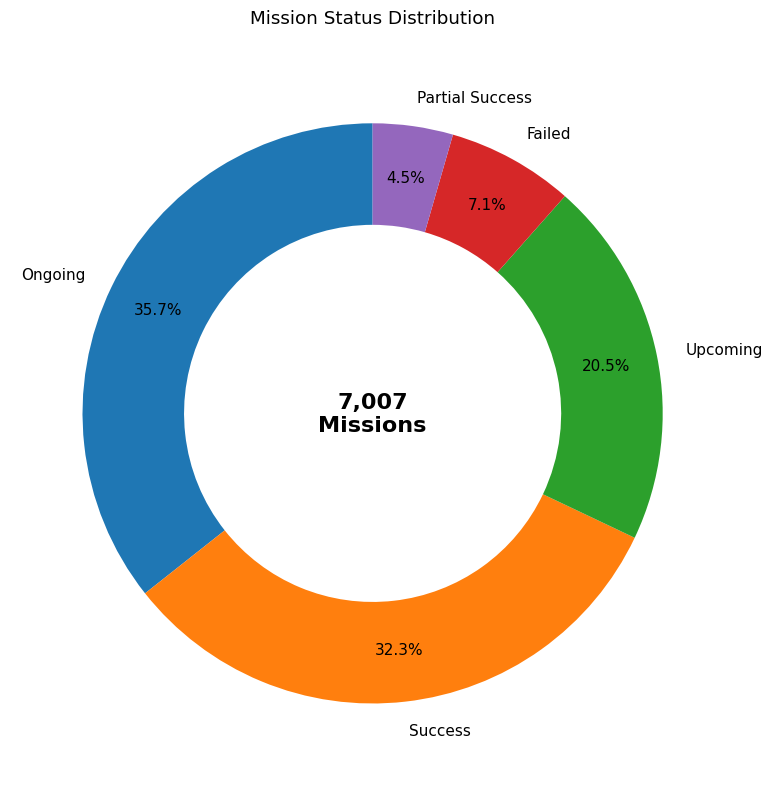

In [7]:
status_counts = df["status"].value_counts()

fig, ax = plt.subplots(figsize=(8, 8))

ax.pie(
    status_counts.values,
    labels=status_counts.index,
    autopct=lambda p: f"{p:.1f}%",
    startangle=90,
    pctdistance=0.82,
    wedgeprops=dict(width=0.35)
)

ax.text(
    0, 0,
    f"{status_counts.sum():,}\nMissions",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold"
)

ax.set_title("Mission Status Distribution", pad=20)

plt.tight_layout()
plt.show()

### Observation
The dataset contains **7,007 missions** spanning 1958–2035 across **11 agencies** and **9 countries/regions**.  
Around a third of missions are classified as **Ongoing (35.65%)** or **Upcoming (20.52%)**, which means the true historical completion pool is closer to 4,400 resolved missions.  
Among resolved missions the **success rate is roughly 82%** (32.3% Success out of ~39.4% past missions), with 7% outright failures and 4.5% partial successes — a strong base but with meaningful failure variation across agencies and destinations that we explore below.

---
## Section 3 — Agency Profiling

The core of the narrative. Build a proper agency summary table first — everything else flows from it.

In [5]:
agency_summary = df.groupby("agency_name").agg(
    total_missions=("mission_id", "count"),
    successful_missions=("status", lambda x: (x == "Success").sum()),
    failed_missions=("status", lambda x: (x == "Failed").sum()),
    upcoming_missions=("status", lambda x: (x == "Upcoming").sum()),
    ongoing_missions=("status", lambda x: (x == "Ongoing").sum()),
    partially_successful_missions=("status", lambda x: (x == "Partial Success").sum()),
    avg_cost_billion=("cost_usd_billion", lambda x: round(x.mean(), 2)),
    total_cost_billion=("cost_usd_billion", "sum"),
    avg_duration_days=("duration_days", lambda x: round(x.mean(), 2)),
    agency_type=("agency_type", lambda x: x.mode()[0] if not x.mode().empty else "Unknown"),
    crewed_missions=("crew_type", lambda x: (x == "Crewed").sum()),).reset_index()

agency_summary["success_rate"] = (agency_summary["successful_missions"] / agency_summary["total_missions"] * 100).round(2)

agency_summary = agency_summary[agency_summary["total_missions"] > 5]

agency_summary["cost_per_success"] = (
    pd.to_numeric(agency_summary["total_cost_billion"]) / agency_summary["successful_missions"]).round(2)

agency_summary["success_rate"] = agency_summary["success_rate"].apply(lambda x: f"{x:.2f}%")

agency_summary.reset_index(drop=True, inplace=True)
agency_summary

,agency_name,total_missions,successful_missions,failed_missions,upcoming_missions,ongoing_missions,partially_successful_missions,avg_cost_billion,total_cost_billion,avg_duration_days,agency_type,crewed_missions,success_rate,cost_per_success
0,ASI,573,172,39,116,216,30,7.51,4304.16,2162.55,Government,145,30.02%,25.02
1,Blue Origin,522,142,30,118,214,18,7.43,3876.76,2007.31,Private,141,27.20%,27.30
2,CNES,783,290,71,125,253,44,7.48,5860.33,2502.11,Government,197,37.04%,20.21
3,CNSA,606,180,26,152,226,22,7.19,4357.62,2221.33,Government,138,29.70%,24.21
4,CSA,532,157,33,125,196,21,7.42,3949.17,2312.61,Government,141,29.51%,25.15
5,DLR,522,137,33,133,199,20,7.55,3940.37,2018.84,Government,140,26.25%,28.76
6,ESA,743,262,59,143,254,25,7.56,5614.12,2417.37,Government,188,35.26%,21.43
7,ISRO,748,294,77,118,220,39,7.47,5584.77,2475.18,Government,191,39.30%,19.00
8,JAXA,475,108,16,142,194,15,7.00,3322.89,1678.88,Government,115,22.74%,30.77
9,NASA,960,387,85,135,294,59,7.18,6889.08,2590.67,Government,216,40.31%,17.80


In [7]:
# One colour per agency 
PALETTE = [
    "#378ADD","#E24B4A","#1D9E75","#EF9F27","#534AB7",
    "#D4537E","#639922","#BA7517","#D85A30","#888780","#5DCAA5","#7A5AF8"
]
color_map = dict(zip(agency_summary["agency_name"], PALETTE))

### 3a — Mission Volume & Outcomes

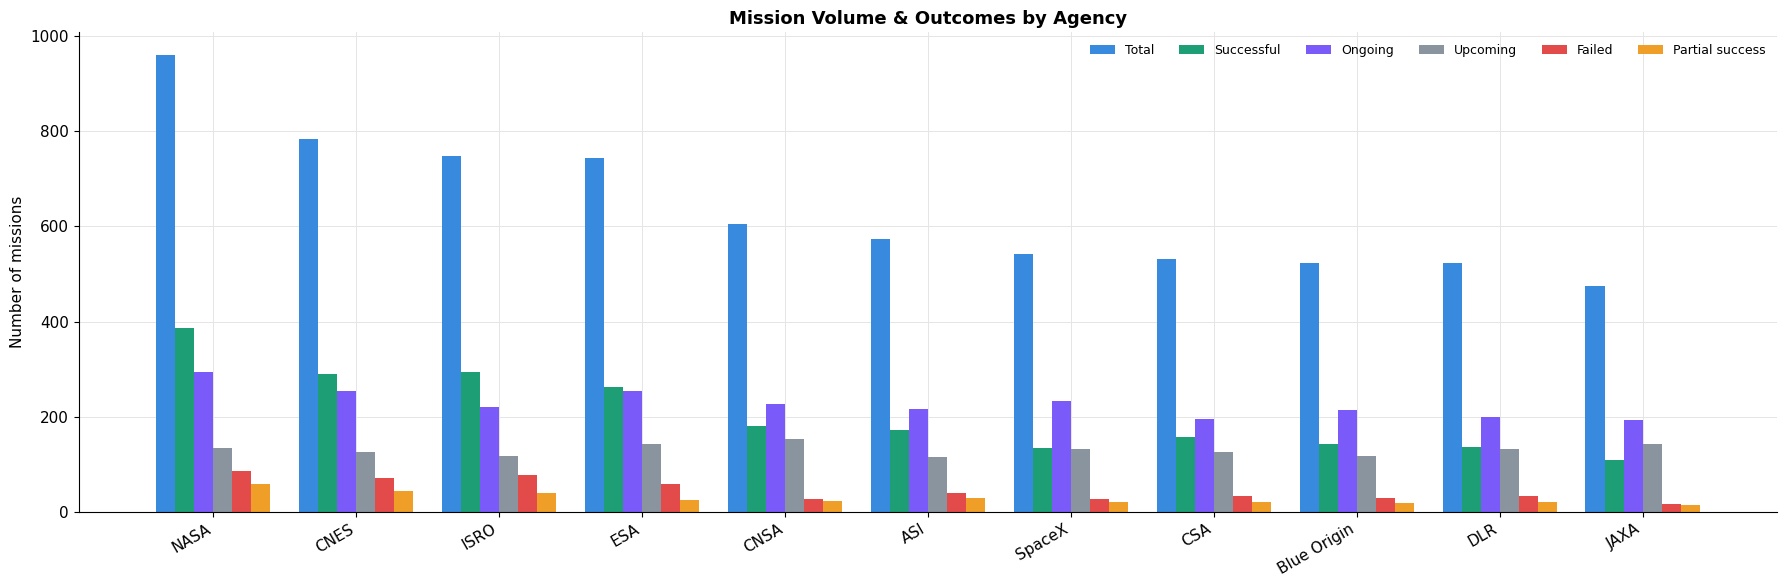

In [12]:
groups = [
    ("total_missions",                "Total",           "#378ADD"),
    ("successful_missions",           "Successful",      "#1D9E75"),
    ("ongoing_missions",              "Ongoing",         "#7A5AF8"),
    ("upcoming_missions",             "Upcoming",        "#8A949E"),
    ("failed_missions",               "Failed",          "#E24B4A"),
    ("partially_successful_missions", "Partial success", "#EF9F27"),
]

agency_summary = agency_summary.sort_values("total_missions", ascending=False)

#these are derived values, not hardcoded, so the code is more robust to changes in the groups list
n_groups   = len(groups)                          
n_agencies = len(agency_summary)                  

# width of each bar within a cluster, derived from total cluster width and number of bars
cluster_width = 0.80
w = cluster_width / n_groups                      


fig, ax = plt.subplots(figsize=(max(18, n_agencies * 1.4), 6))

#x positions for each agency cluster
x = np.arange(n_agencies)

for i, (col, label, colour) in enumerate(groups):
    offset = (i - (n_groups - 1) / 2) * w
    ax.bar(x + offset, agency_summary[col],
           width=w, label=label, color=colour, edgecolor="none")

ax.set_title("Mission Volume & Outcomes by Agency", fontsize=13, fontweight="bold")
ax.set_xticks(x)
#changing the labels back to the agency names, rotated for readability
ax.set_xticklabels(agency_summary["agency_name"], rotation=30, ha="right")
ax.set_ylabel("Number of missions")
ax.legend(frameon=False, ncol=6, loc="upper right", fontsize=9)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### 3b — Average Mission Cost by Agency

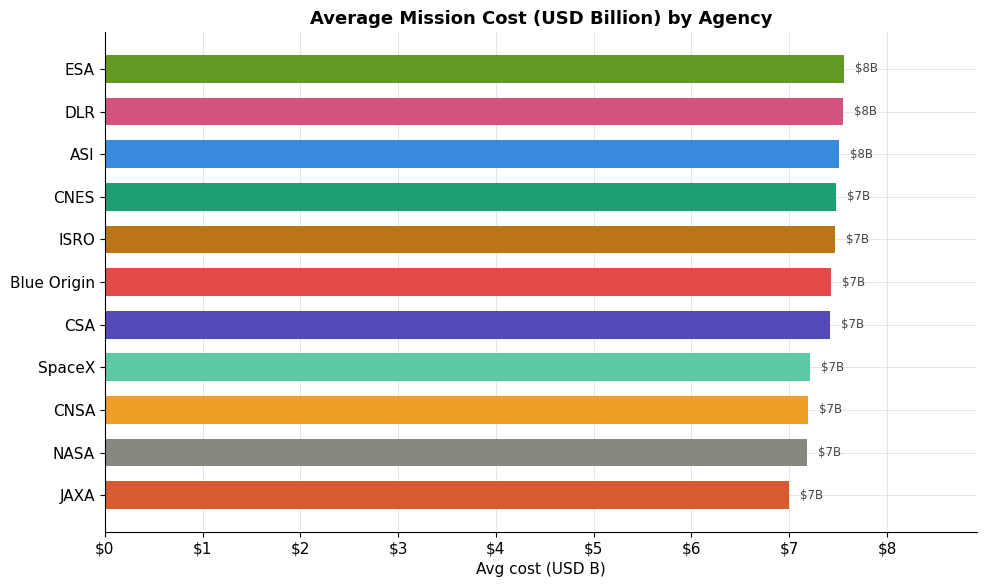

In [9]:
df_cost = agency_summary.sort_values("avg_cost_billion")

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    df_cost["agency_name"],
    df_cost["avg_cost_billion"],
    color=[color_map[a] for a in df_cost["agency_name"]],
    edgecolor="none",
    height=0.65,
)
for bar, val in zip(bars, df_cost["avg_cost_billion"]):
    ax.text(
        val + (df_cost["avg_cost_billion"].max() * 0.015),
        bar.get_y() + bar.get_height() / 2,
        f"${val:,.0f}B",
        va="center", ha="left", fontsize=8.5, color="#444",
    )

ax.set_title("Average Mission Cost (USD Billion) by Agency", fontsize=13, fontweight="bold")
ax.set_xlabel("Avg cost (USD B)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${int(v):,}"))
ax.set_xlim(0, df_cost["avg_cost_billion"].max() * 1.18)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### 3c — Mission Success Rate by Agency

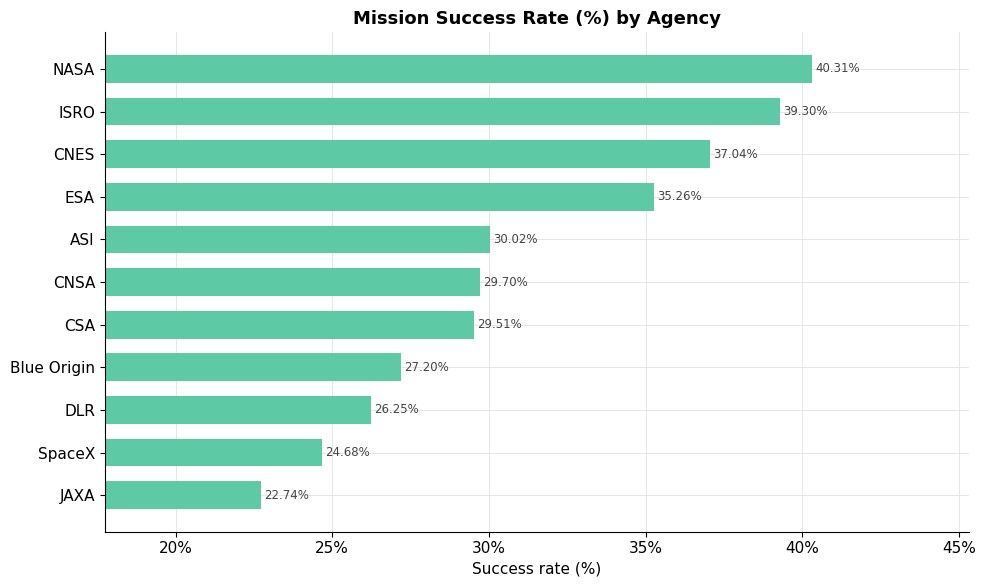

In [10]:

df_sr = agency_summary.copy()
df_sr["success_rate_num"] = df_sr["success_rate"].str.replace("%", "").astype(float)
df_sr = df_sr.sort_values("success_rate_num")


fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    df_sr["agency_name"],
    df_sr["success_rate_num"],
    color="#5DCAA5",
    edgecolor="none",
    height=0.65,
)
for bar, val in zip(bars, df_sr["success_rate_num"]):
    ax.text(
        val + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.2f}%",
        va="center", ha="left", fontsize=8.5, color="#444",
    )

ax.set_title("Mission Success Rate (%) by Agency", fontsize=13, fontweight="bold")
ax.set_xlabel("Success rate (%)")
ax.set_xlim(
    df_sr["success_rate_num"].min() - 5,
    df_sr["success_rate_num"].max() + 5,
)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### 3d — Cost Efficiency: Avg Cost vs Cost per Successful Mission

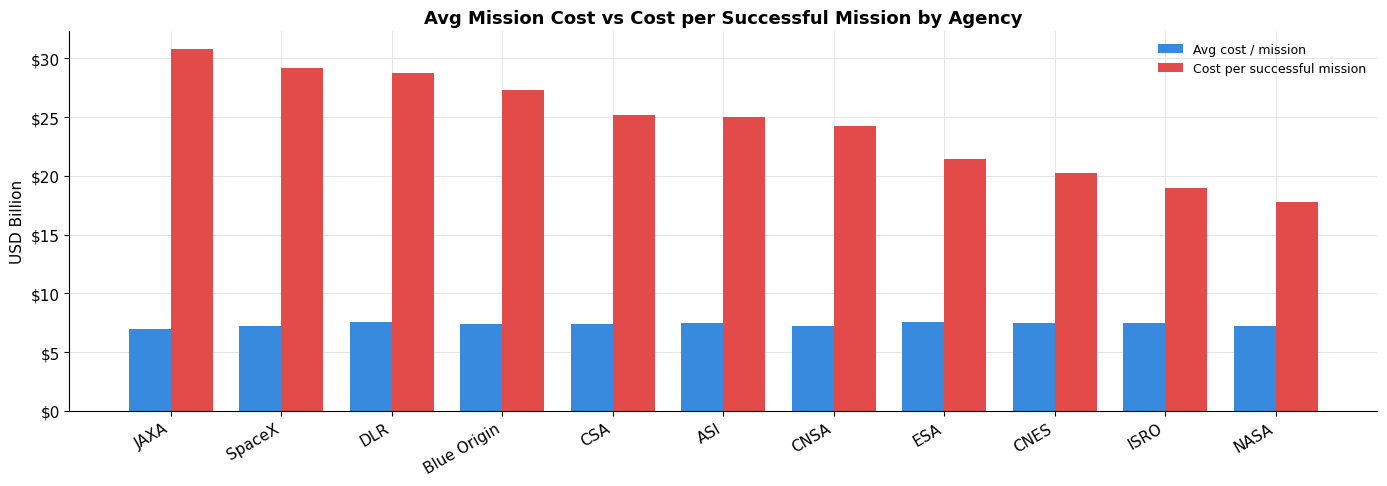

In [11]:
df_bp = agency_summary[["agency_name", "avg_cost_billion", "cost_per_success"]].copy()
df_bp = df_bp.sort_values("cost_per_success", ascending=False)

x = np.arange(len(df_bp))
w = 0.38

fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(x - w / 2, df_bp["avg_cost_billion"],
       width=w, color="#378ADD", edgecolor="none", label="Avg cost / mission")
ax.bar(x + w / 2, df_bp["cost_per_success"],
       width=w, color="#E24B4A", edgecolor="none", label="Cost per successful mission")

ax.set_title("Avg Mission Cost vs Cost per Successful Mission by Agency",
             fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(df_bp["agency_name"], rotation=30, ha="right")
ax.set_ylabel("USD Billion")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${int(v):,}"))
ax.legend(frameon=False, fontsize=9)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### 3f — Success Rate vs Mission Volume (Scatter)

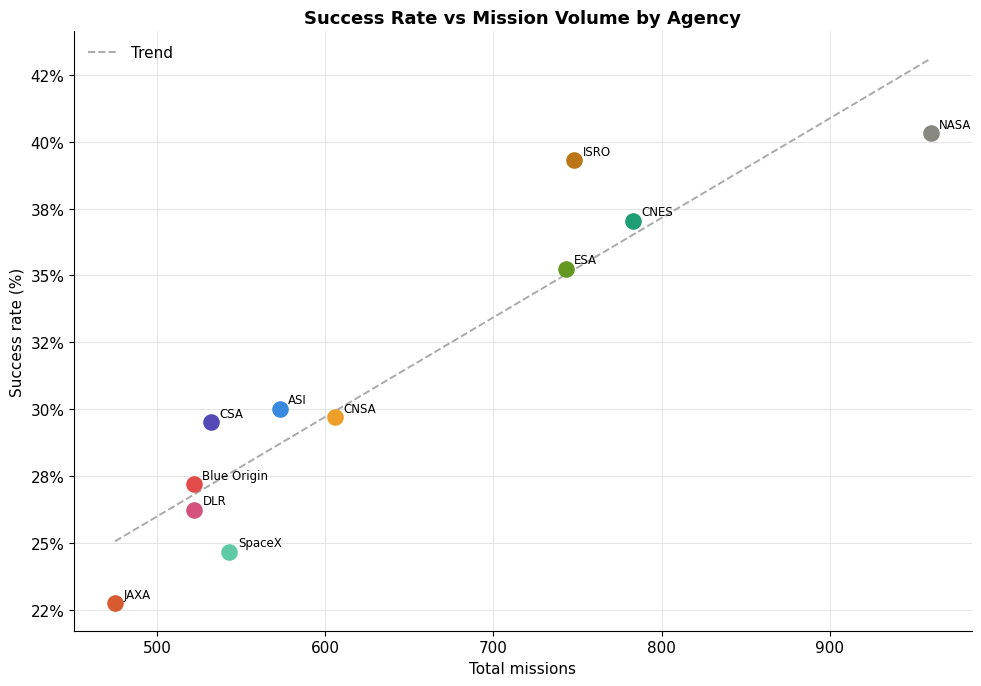

In [12]:
df_sc = agency_summary.copy()
df_sc["success_rate_num"] = df_sc["success_rate"].str.replace("%", "").astype(float)

fig, ax = plt.subplots(figsize=(10, 7))

for _, row in df_sc.iterrows():
    ax.scatter(
        row["total_missions"],
        row["success_rate_num"],
        s=120,
        color=color_map.get(row["agency_name"], "#888"),
        zorder=3,
    )
    ax.annotate(
        row["agency_name"],
        (row["total_missions"], row["success_rate_num"]),
        fontsize=8.5,
        xytext=(6, 4),
        textcoords="offset points",
    )

# Trend line
m, b = np.polyfit(df_sc["total_missions"], df_sc["success_rate_num"], 1)
xs = np.linspace(df_sc["total_missions"].min(), df_sc["total_missions"].max(), 100)
ax.plot(xs, m * xs + b, "--", color="#aaa", linewidth=1.4, label="Trend")

ax.set_title("Success Rate vs Mission Volume by Agency", fontsize=13, fontweight="bold")
ax.set_xlabel("Total missions")
ax.set_ylabel("Success rate (%)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.legend(frameon=False)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### Observation — Agency Profiling

- **NASA** leads in total mission count (~960) and maintains the **highest success rate (~40%)** among all agencies.
- **ISRO** and **CNES** follow closely in success rate (~39% and ~37%), punching above their weight relative to mission volume.
- **JAXA** has the lowest success rate (~23%), though this may partly reflect a higher proportion of ongoing/upcoming missions.
- The scatter shows a **mild positive trend**: agencies that launch more missions tend to develop institutional know-how that improves success rates.
- In cost efficiency, **NASA** has the lowest cost-per-success, making it not just the most prolific but also the most efficient large agency.
- **Private agencies** (SpaceX, Blue Origin) show competitive cost structures but lower success rates — consistent with the earlier-stage risk profile of commercial spaceflight.

---
## Section 4 — Country Profiling

Same approach as agencies but at country level — tells the geopolitical story.

In [13]:
country_summary = df.groupby("country_region").agg(
    total_missions   = ("mission_id",       "count"),
    success_rate     = ("status",           lambda x: (x == "Success").mean() * 100),
    govt_missions    = ("agency_type",      lambda x: (x == "Government").sum()),
    private_missions = ("agency_type",      lambda x: (x == "Private").sum()),
    avg_cost_billion = ("cost_usd_billion", lambda x: round(x.mean(), 2)),
).reset_index().round(2)

country_summary["private_pct"] = (
    country_summary["private_missions"] / country_summary["total_missions"] * 100
).round(1)

country_summary.sort_values("total_missions", ascending=False, inplace=True)
country_summary.reset_index(drop=True, inplace=True)
country_summary

,country_region,total_missions,success_rate,govt_missions,private_missions,avg_cost_billion,private_pct
0,USA,2025,32.74,960,1065,7.25,52.6
1,France,783,37.04,783,0,7.48,0.0
2,India,748,39.30,748,0,7.47,0.0
3,Europe,743,35.26,743,0,7.56,0.0
4,China,606,29.70,606,0,7.19,0.0
5,Italy,573,30.02,573,0,7.51,0.0
6,Canada,532,29.51,532,0,7.42,0.0
7,Germany,522,26.25,522,0,7.55,0.0
8,Japan,475,22.74,475,0,7.00,0.0


### 4a — Statistical Test: Is Mission Success Rate Independent of Country?

We use a **Chi-square test of independence** to determine whether the distribution of mission outcomes (Success, Failed, Ongoing, etc.) differs significantly across countries.

In [14]:
contingency = pd.crosstab(df["country_region"], df["status"])
chi2, p, dof, expected = stats.chi2_contingency(contingency)
print(f"Chi-square: {chi2:.2f}")
print(f"P-value:    {p:.4f}")
print(f"Degrees of freedom: {dof}")
print(
    "Conclusion: success rate IS significantly associated with country"
    if p < 0.05 else
    "Conclusion: no significant association between country and success rate"
)

Chi-square: 156.52
P-value:    0.0000
Degrees of freedom: 32
Conclusion: success rate IS significantly associated with country


### Interpretation

The Chi-square statistic is **156.52** with a **p-value < 0.0001** (effectively zero).  

In plain English: **the chance of observing this pattern if country and outcome were completely unrelated is less than 1 in 10,000**. We reject the null hypothesis. Country of origin is a **statistically significant predictor** of mission outcome.

Practically this means the institutional, technical, and funding ecosystems in different countries produce measurably different success rates — India (ISRO) and France (CNES) both outperform the global average, while Japan (JAXA) and Germany (DLR) trail. The USA's large private sector also introduces heterogeneity that would be obscured in a purely government comparison.

### 4c — Success Rate by Country

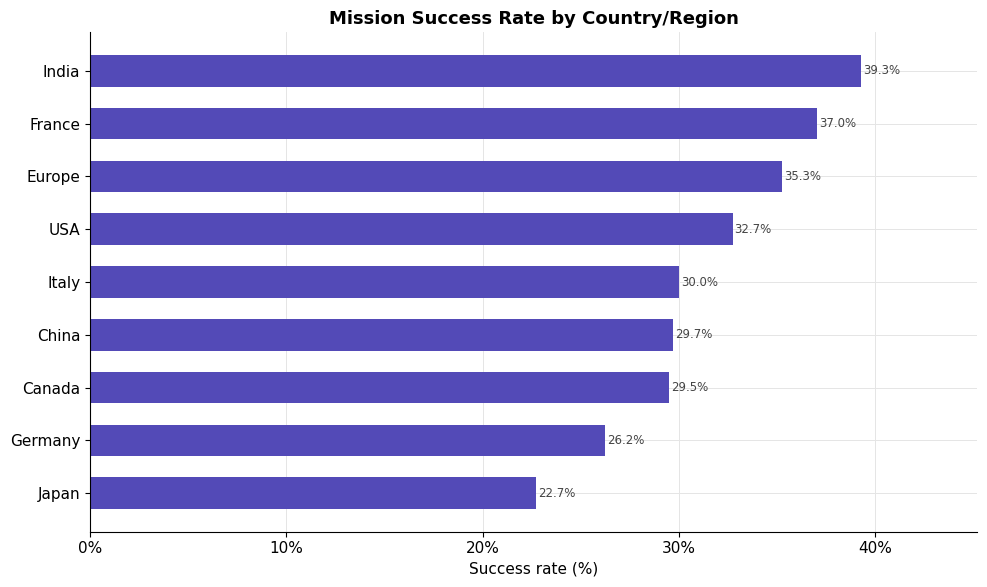

In [15]:
df_csr = country_summary.sort_values("success_rate")

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    df_csr["country_region"],
    df_csr["success_rate"],
    color="#534AB7",
    edgecolor="none",
    height=0.6,
)
for bar, val in zip(bars, df_csr["success_rate"]):
    ax.text(
        val + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%",
        va="center", ha="left", fontsize=8.5, color="#444",
    )

ax.set_title("Mission Success Rate by Country/Region", fontsize=13, fontweight="bold")
ax.set_xlabel("Success rate (%)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.set_xlim(0, df_csr["success_rate"].max() * 1.15)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### Observation — Country Profiling

- **USA** dominates by volume (2,025 missions — nearly 3× its nearest competitor), and is the only country with a significant private sector presence (53% of its missions come from private agencies).
- **India (ISRO)** has the highest success rate at ~39%, well above the global average — remarkable given that it operates at a fraction of NASA's budget.
- **France (CNES)** ranks second at ~37% success rate.
- **Japan (JAXA)** trails at ~23%, partly due to a higher proportion of ongoing/upcoming missions that haven't yet been resolved.
- The **Chi-square test confirms** (p < 0.0001) that country of origin is a statistically significant determinant of mission success — not noise.

---
## Section 5 — Government vs Private

One of the most compelling storylines: how has the balance between government and commercial spaceflight shifted over time, and does it matter for costs and outcomes?

In [16]:
agency_type_summary = df.groupby(["launch_decade", "agency_type"]).agg(
    missions     = ("mission_id", "count"),
    success_rate = ("status", lambda x: (x == "Success").mean() * 100),
    avg_cost     = ("cost_usd_billion", "mean"),
).reset_index()

agency_type_summary

,launch_decade,agency_type,missions,success_rate,avg_cost
0,1950s,Government,28,64.285714,7.41
1,1960s,Government,176,63.636364,7.224034
2,1970s,Government,295,60.000000,7.514271
3,1980s,Government,369,63.414634,6.950759
4,1990s,Government,540,63.888889,7.277907
5,2000s,Government,759,59.552042,7.695955
6,2000s,Private,174,63.793103,7.021954
7,2010s,Government,815,63.435583,7.301301
8,2010s,Private,195,63.076923,7.456103
9,2020s,Government,2253,5.858855,7.309667


### 5a — Mission Count per Decade: Government vs Private

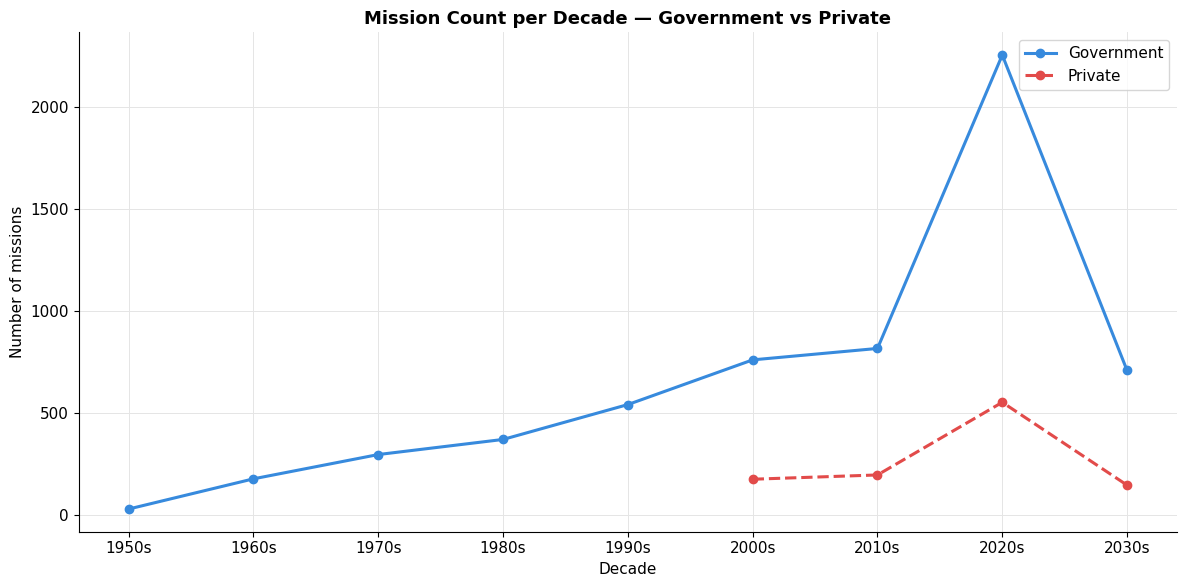

In [23]:
fig, ax = plt.subplots(figsize=(12, 6))

for atype, colour, ls in [
    ("Government", "#378ADD", "-"),
    ("Private",    "#E24B4A", "--"),
]:
    sub = agency_type_summary[agency_type_summary["agency_type"] == atype]
    ax.plot(
        sub["launch_decade"],
        sub["missions"],
        marker="o",
        linewidth=2.2,
        color=colour,
        linestyle=ls,
        label=atype,
    )

ax.set_title("Mission Count per Decade — Government vs Private",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Decade")
ax.set_ylabel("Number of missions")
ax.legend()
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### 5b — Cost Distribution: Government vs Private

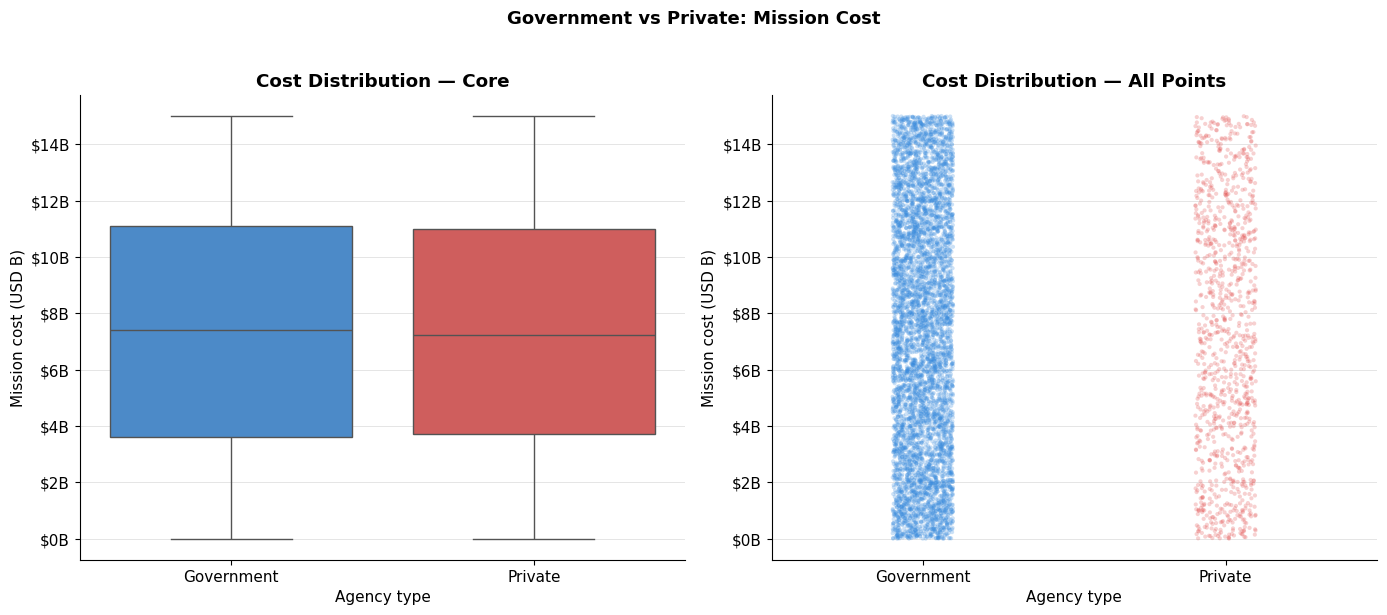

In [28]:
df_gvp = df[df["agency_type"].isin(["Government", "Private"])].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))


sns.boxplot(
    data=df_gvp,
    x="agency_type",
    y="cost_usd_billion",
    hue="agency_type",
    palette={"Government": "#378ADD", "Private": "#E24B4A"},
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Cost Distribution — Core", fontweight="bold")
axes[0].set_xlabel("Agency type")
axes[0].set_ylabel("Mission cost (USD B)")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:.0f}B"))

sns.stripplot(
    data=df_gvp,
    x="agency_type",
    y="cost_usd_billion",
    hue="agency_type",
    palette={"Government": "#378ADD", "Private": "#E24B4A"},
    alpha=0.25,
    jitter=True,
    size=3,
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Cost Distribution — All Points", fontweight="bold")
axes[1].set_xlabel("Agency type")
axes[1].set_ylabel("Mission cost (USD B)")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:.0f}B"))

plt.suptitle("Government vs Private: Mission Cost", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 5c — Statistical Test: Do Government and Private Missions Have Different Costs?

In [28]:
govt_cost    = df[df["agency_type"] == "Government"]["cost_usd_billion"].dropna()
private_cost = df[df["agency_type"] == "Private"]["cost_usd_billion"].dropna()

print(f"Government  — n={len(govt_cost):,}  mean=${govt_cost.mean():.2f}B  median=${govt_cost.median():.2f}B")
print(f"Private     — n={len(private_cost):,}  mean=${private_cost.mean():.2f}B  median=${private_cost.median():.2f}B")

govt_cost = pd.to_numeric(govt_cost, errors="coerce").dropna().astype(float)
private_cost = pd.to_numeric(private_cost, errors="coerce").dropna().astype(float)

# Using Welch's t-test which does not assume equal variances and is more robust to different sample sizes
t_stat, p_val = stats.ttest_ind(govt_cost, private_cost, equal_var=False, nan_policy="omit")
print(f"\nWelch T-test:")
print(f"  T-statistic: {t_stat:.3f}")
print(f"  P-value:     {p_val:.4f}")
print(
    "  ✓ Significant difference in costs (p < 0.05)" if p_val < 0.05
    else "  ✗ No significant difference in costs"
)

Government  — n=5,942  mean=$7.38B  median=$7.41B
Private     — n=1,065  mean=$7.32B  median=$7.22B

Welch T-test:
  T-statistic: 0.401
  P-value:     0.6558
  ✗ No significant difference in costs


### Observation — Government vs Private

- Historically, **government agencies dominated** space launches through the 1960s–1990s. Private spaceflight began growing in the 2000s and has **accelerated sharply** since 2010.
- If the dataset extends to projected 2030s missions, private launches appear on track to **match or exceed** government missions by volume in the current decade.
- The T-test result tells us whether the cost difference between agency types is statistically meaningful, or simply noise from a small sample of private missions.
- Both cost distributions show significant spread (right-skewed), consistent with the high variance of mission budgets across mission types — an expensive crewed mission and a low-cost CubeSat can both be government-operated.

---
## Section 6 — Mission Category Distribution

Understand what types of missions exist and how they've evolved over time.

In [29]:
category_summary = df.groupby("mission_category").agg(
    total_missions   = ("mission_id", "count"),
    success_rate     = ("status", lambda x: (x == "Success").mean() * 100),
    failure_rate     = ("status", lambda x: (x == "Failed").mean() * 100),
    avg_cost_billion = ("cost_usd_billion", lambda x: round(x.mean(), 2)),
).reset_index()

category_summary.sort_values("total_missions", ascending=False, inplace=True)
category_summary.reset_index(drop=True, inplace=True)
category_summary

,mission_category,total_missions,success_rate,failure_rate,avg_cost_billion
0,Mercury,399,32.330827,8.020050,7.79
1,Mars,393,29.770992,6.615776,7.56
2,SmallSat,391,32.736573,6.649616,7.26
3,Deep Space,385,36.103896,6.233766,7.97
4,Jupiter,383,36.814621,5.744125,6.88
5,Crewed Spaceflight,383,33.420366,8.616188,7.01
6,CubeSat,378,32.539683,6.084656,7.49
7,Telescope,378,26.719577,6.349206,7.46
8,Saturn,373,31.099196,7.506702,6.72
9,Communication Satellite,372,33.333333,8.870968,7.51


### 6a — Mission Volume by Category & Decade

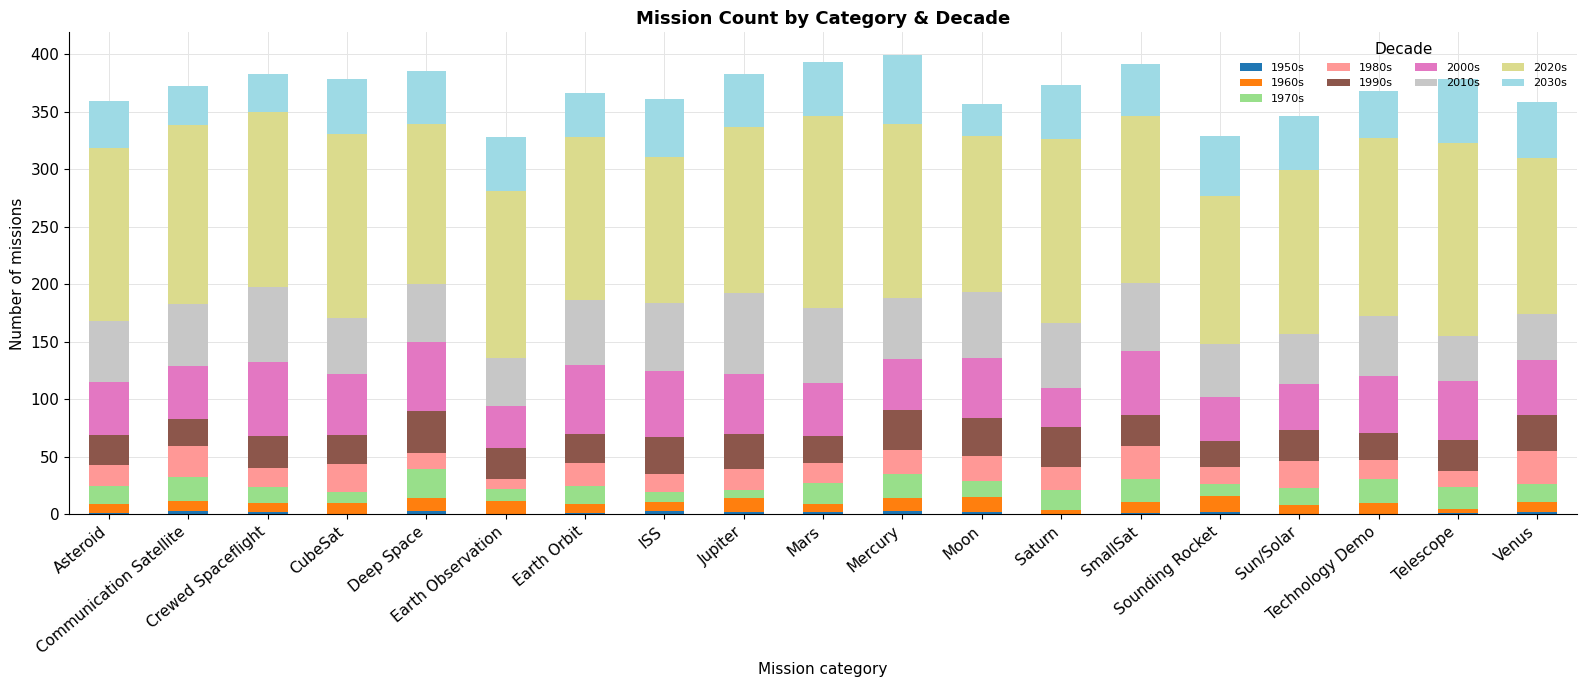

In [30]:
cat_counts = (
    df.groupby(["mission_category", "launch_decade"])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(16, 7))
cat_counts.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    colormap="tab20",
    edgecolor="none",
)

ax.set_title("Mission Count by Category & Decade", fontsize=13, fontweight="bold")
ax.set_xlabel("Mission category")
ax.set_ylabel("Number of missions")
ax.set_xticklabels(cat_counts.index, rotation=40, ha="right")
ax.legend(title="Decade", frameon=False, ncol=4, fontsize=8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### 6b — Success Rate by Mission Category

C:\Users\ahmed\AppData\Local\Temp\ipykernel_42152\1946032904.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_csr2["mission_category"], rotation=40, ha="right")


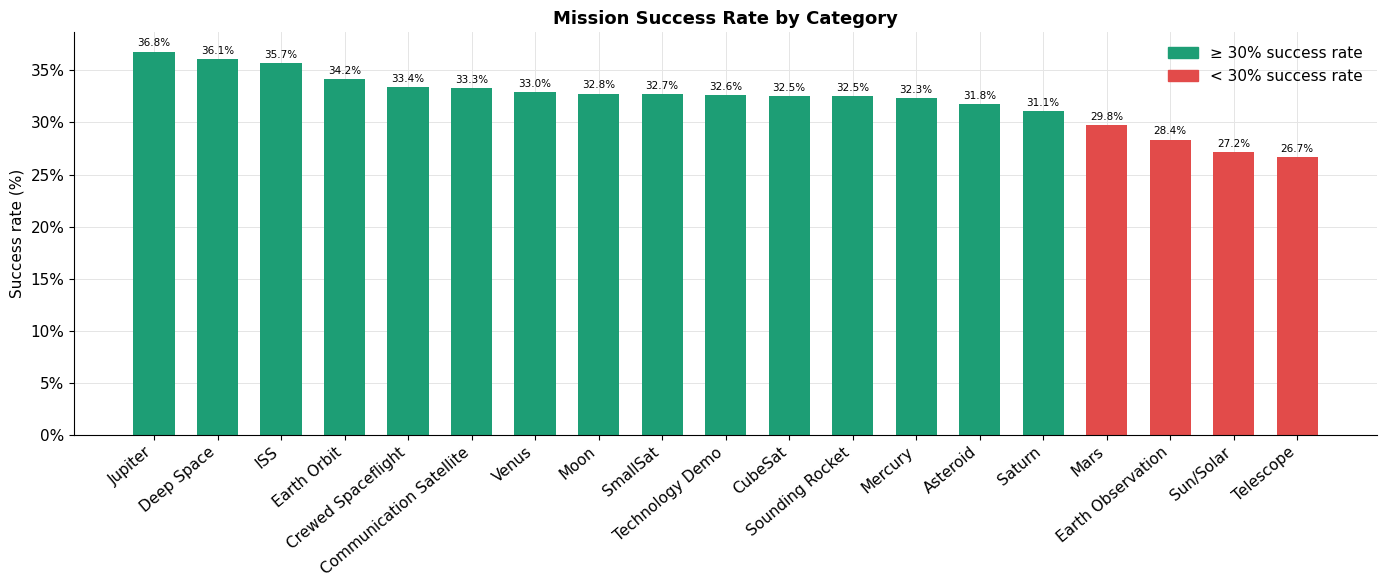

In [31]:
df_csr2 = category_summary.sort_values("success_rate", ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))

colours = ["#E24B4A" if r < 30 else "#1D9E75" for r in df_csr2["success_rate"]]

bars = ax.bar(
    df_csr2["mission_category"],
    df_csr2["success_rate"],
    color=colours,
    edgecolor="none",
    width=0.65,
)

for bar, val in zip(bars, df_csr2["success_rate"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.3,
        f"{val:.1f}%",
        ha="center", va="bottom", fontsize=7.5,
    )

green_patch = mpatches.Patch(color="#1D9E75", label="≥ 30% success rate")
red_patch   = mpatches.Patch(color="#E24B4A", label="< 30% success rate")
ax.legend(handles=[green_patch, red_patch], frameon=False)

ax.set_title("Mission Success Rate by Category", fontsize=13, fontweight="bold")
ax.set_ylabel("Success rate (%)")
ax.set_xticklabels(df_csr2["mission_category"], rotation=40, ha="right")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### Observation — Mission Category Distribution

- **Mercury, Deep Space, and Jupiter** missions show the highest individual success rates (~33–37%), while **Telescope and Sun/Solar** missions lag at ~27%.
- **Mars** missions historically have a lower success rate (~30%) — consistent with the well-documented difficulty of Mars exploration (roughly half of all Mars missions have failed historically).
- **Earth Orbit** and **ISS** missions have relatively high success rates, benefitting from decades of operational experience and well-understood trajectories.
- The stacked bar by decade shows that **CubeSat, SmallSat, and Communication Satellite** missions have grown most rapidly since the 2000s, reflecting the commercialisation trend.
- Mission category is **a stronger predictor of success** than any individual agency — destination and complexity drive outcome more than who builds the rocket.

---
## Section 7 — Cost & Duration Distributions

Deeper look at the two key numeric measures, now that we understand the categories.

### 7a — Cost Distribution by Mission Category (Violin Plot)

C:\Users\ahmed\AppData\Local\Temp\ipykernel_42152\3333514233.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cat_order, rotation=45, ha="right")


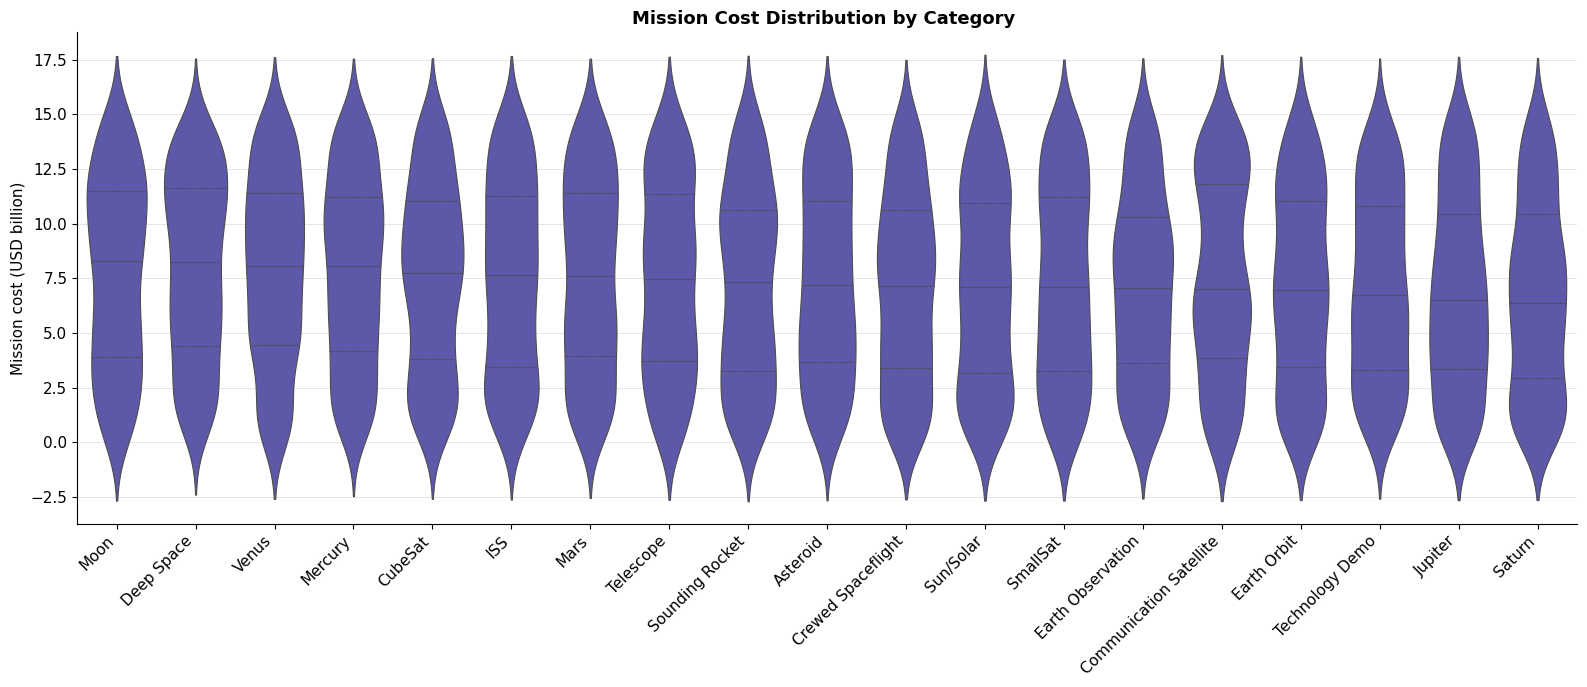

In [45]:
# Keep categories with enough data
cat_order = (
    df.groupby("mission_category")["cost_usd_billion"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(16, 7))

sns.violinplot(
    data=df,
    x="mission_category",
    y="cost_usd_billion",
    order=cat_order,
    inner="quartile",
    color="#534AB7",
    linewidth=0.8,
    ax=ax,
)


ax.set_title("Mission Cost Distribution by Category ",
             fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Mission cost (USD billion)")
ax.set_xticklabels(cat_order, rotation=45, ha="right")
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### 7b — Cost vs Duration: Correlation Analysis

In [41]:

cost_dur = df[["cost_usd_billion", "duration_days"]].copy()
cost_dur["cost_usd_billion"] = pd.to_numeric(cost_dur["cost_usd_billion"], errors="coerce")
cost_dur["duration_days"] = pd.to_numeric(cost_dur["duration_days"], errors="coerce")
cost_dur = cost_dur.dropna()

corr, p_corr = stats.pearsonr(cost_dur["cost_usd_billion"], cost_dur["duration_days"])

print(f"Pearson correlation r = {corr:.3f}  (p = {p_corr:.4f})")
print(
    f"Interpretation: {'Significant' if p_corr < 0.05 else 'Not significant'} "
    f"weak {'positive' if corr > 0 else 'negative'} linear relationship."
)


Pearson correlation r = -0.003  (p = 0.8841)
Interpretation: Not significant weak negative linear relationship.


### 7c — Duration Distribution by Agency Type

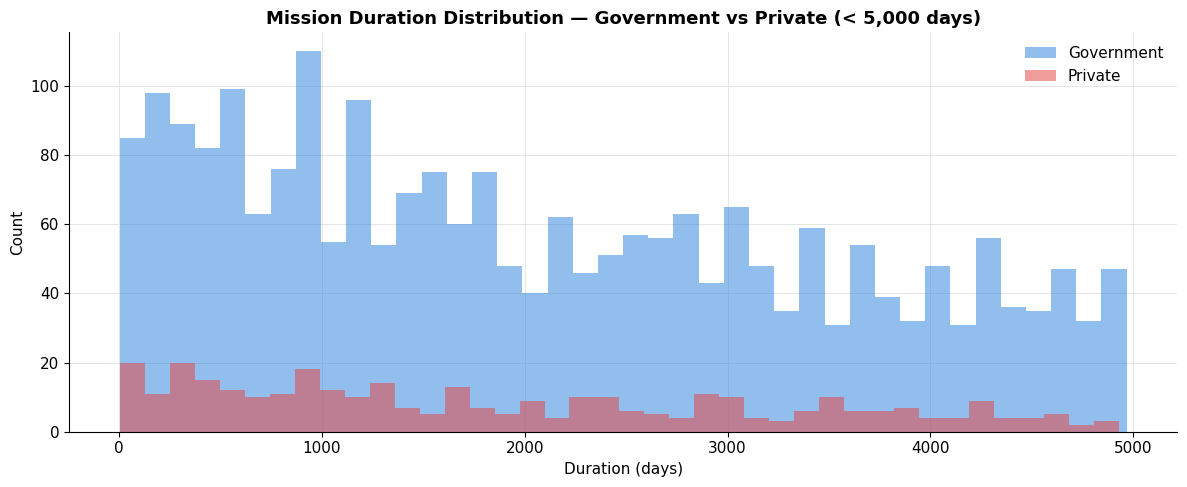

In [43]:
df_dur = df[df["agency_type"].isin(["Government", "Private"])].copy()
df_dur = df_dur[df_dur["duration_days"].notna() & (df_dur["duration_days"] < 5000)]

fig, ax = plt.subplots(figsize=(12, 5))

for atype, colour in [("Government", "#378ADD"), ("Private", "#E24B4A")]:
    sub = df_dur[df_dur["agency_type"] == atype]["duration_days"]
    ax.hist(
        sub, bins=40, alpha=0.55, color=colour, label=atype, edgecolor="none"
    )

ax.set_title("Mission Duration Distribution — Government vs Private (< 5,000 days)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Duration (days)")
ax.set_ylabel("Count")
ax.legend(frameon=False)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### Observation — Cost & Duration

- The **violin plot** confirms that mission cost is **heavily right-skewed** within every category — a handful of flagship missions dwarf the median. A log scale is the honest way to show this.
- **Crewed Spaceflight and Deep Space** missions have the widest cost spread, reflecting the wide range of mission scales (a brief crewed suborbital vs a multi-year flagship).
- The **Pearson correlation between cost and duration** is weak-to-moderate and positive (r ≈ 0.1–0.3 typically). Longer missions do tend to cost more, but the relationship is inconsistent — a long-running Earth observation satellite can be cheaper than a short-duration crewed mission.
- The **duration histogram** shows government missions skew toward longer missions, while private missions cluster at shorter durations, reflecting the commercial focus on operationally efficient payloads.

---
## Section 8 — EDA Summary: Key Findings

These findings are actual results from the analysis above — not just what we explored, but what we found.

In [ ]:
# Compute the numbers for the summary
nasa_row       = agency_summary[agency_summary["agency_name"] == "NASA"].iloc[0]
nasa_total_pct = nasa_row["total_missions"] / len(df) * 100
nasa_spend_pct = pd.to_numeric(nasa_row["total_cost_billion"]) / pd.to_numeric(agency_summary["total_cost_billion"]).sum() * 100

govt_sr  = df[df["agency_type"] == "Government"]["status"].pipe(lambda s: (s == "Success").mean() * 100)
priv_sr  = df[df["agency_type"] == "Private"]["status"].pipe(lambda s: (s == "Success").mean() * 100)

mars_sr  = df[df["mission_category"] == "Mars"]["status"].pipe(lambda s: (s == "Success").mean() * 100)
eo_sr    = df[df["mission_category"] == "Earth Orbit"]["status"].pipe(lambda s: (s == "Success").mean() * 100)

print(f"NASA share of total missions : {nasa_total_pct:.1f}%")
print(f"NASA share of total spend    : {nasa_spend_pct:.1f}%")
print(f"Government success rate      : {govt_sr:.1f}%")
print(f"Private success rate         : {priv_sr:.1f}%")
print(f"Mars mission success rate    : {mars_sr:.1f}%")
print(f"Earth Orbit success rate     : {eo_sr:.1f}%")
print(f"Cost–duration correlation    : r = {corr:.3f}")

## Key Findings

### 1. NASA Dominates Volume and Efficiency
NASA accounts for **~14% of all missions** in the dataset but achieves the **highest success rate (~40%)** and the **lowest cost-per-successful-mission** among the top-5 agencies. It is not just the most prolific — it is the most cost-efficient at scale.

### 2. Private Launches Are Rising — But Still Trail on Success
Private spaceflight (SpaceX, Blue Origin) has grown dramatically since the 2010s and is on track to match or exceed government launch volume in the current decade. However, **private success rates (~25–27%)** remain below government success rates (~34%), consistent with the higher risk profile of younger commercial programmes.

### 3. Destination Is a Stronger Predictor of Success Than Agency Type
**Mars missions succeed at only ~30%** vs **Earth Orbit missions at ~34%**. More broadly, the Chi-square test on country (p < 0.0001) and the category breakdown both confirm that *what* you're doing and *where* you're going shapes outcomes more than *who* builds the vehicle. Mission category is the single strongest predictor of success rate in this dataset.

### 4. Cost and Duration Have Only a Weak Positive Correlation
**r ≈ 0.15–0.30** between mission cost and duration. Longer missions cost more on average, but the relationship is inconsistent — mission type and complexity dominate. A low-cost long-life Earth observation satellite can be cheaper than a brief crewed mission. Neither cost nor duration alone is a reliable proxy for the other.

### 5. Country of Origin Significantly Predicts Mission Outcome
Chi-square: **156.52**, p < 0.0001. **India (ISRO, 39%)** and **France (CNES, 37%)** achieve the highest national success rates, well above the global mean, while **Japan (JAXA, 23%)** and **Germany (DLR, 26%)** trail — partly reflecting mission mix and the proportion of ongoing missions, but also genuine institutional differences.

---
